# Preprocess MUG

In [1]:
import tensorflow as tf
import tensorflow_io as tfio

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2

from matplotlib import pyplot as plt
from IPython.display import display, clear_output, update_display
from tqdm.notebook import tqdm

from joblib import Memory
from joblib import Parallel, delayed

2023-06-29 17:47:34.474756: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-29 17:47:34.535875: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
NEW_SIZE = 256

In [3]:
# Normalizing the images to [-1, 1]
def normalize(sequence):
  return (sequence / 127.5) - 1

# Undo normalizing the images to [0, 255]
@tf.function
def normalized_sequence_to_images(sequence):
  return tf.cast((sequence + 1) * 127.5, tf.uint8)

In [4]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    if n_frames > 20:
        plot_sequence = plot_sequence[:20]
        n_frames = 20
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [5]:
def get_save_path(video_path, save_folder, video_folder="mug"):
    save_path = str(video_path).replace(video_folder, save_folder)
    return Path(save_path).with_suffix(".npy")

def load_video(path):
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video = []
    for i in range(n):
        ret, frame = cap.read()
        if ret:
            video.append(frame)
    cap.release()
    return np.array(video)
    

# resize video lanczos4
def resize_video(video, size=NEW_SIZE):
    resized = []
    for frame in video:
        if frame is not None:
            resized.append(cv2.resize(frame, (size,size), interpolation=cv2.INTER_LANCZOS4))
    return resized

# BRG to RGB
def bgr_to_rgb(video):
    return np.array([cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in video])

def save_video(video, video_path, save_folder):
    video_save_path = get_save_path(video_path, save_folder)
    video_save_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(str(video_save_path), video)
        
# load videos from npy
def load_videos(videos_paths, n=None):
    videos_paths = list(videos_paths)
    print(videos_paths)
    if n is None:
        n = len(videos_paths)
    else:
        videos_paths = videos_paths[:n]
    videos = []
    for path in tqdm(videos_paths, total=n):
        videos.append(np.load(path))
    return videos

def process_videos(videos_paths, save_folder):
    videos_paths = list(videos_paths)
    n = len(videos_paths)
    for video_path in tqdm(videos_paths, total=n):
        video = load_video(video_path)
        if NEW_SIZE != 448:
            video = resize_video(video)
        video = bgr_to_rgb(video)
        video = normalize(video)
        save_video(video, video_path, save_folder)


In [6]:
mug_path = Path('../data/mug/')
save_folder = f'mug{NEW_SIZE}'
process_videos(list(mug_path.glob('**/*.avi')), save_folder)

  0%|          | 0/1033 [00:00<?, ?it/s]

In [7]:
save_path = Path(f'../data/{save_folder}/')
videos = load_videos(save_path.glob('**/*.npy'))
len(videos)
print(videos[0].shape)

[PosixPath('../data/mug256/075/surprise/take002/video.npy'), PosixPath('../data/mug256/075/surprise/take004/video.npy'), PosixPath('../data/mug256/075/surprise/take001/video.npy'), PosixPath('../data/mug256/075/surprise/take003/video.npy'), PosixPath('../data/mug256/075/disgust/take002/video.npy'), PosixPath('../data/mug256/075/disgust/take004/video.npy'), PosixPath('../data/mug256/075/disgust/take005/video.npy'), PosixPath('../data/mug256/075/disgust/take003/video.npy'), PosixPath('../data/mug256/075/disgust/take000/video.npy'), PosixPath('../data/mug256/075/fear/take003nsg/video.npy'), PosixPath('../data/mug256/075/fear/take002nsg/video.npy'), PosixPath('../data/mug256/075/sadness/take002/video.npy'), PosixPath('../data/mug256/075/sadness/take001/video.npy'), PosixPath('../data/mug256/075/sadness/take003/video.npy'), PosixPath('../data/mug256/075/sadness/take000/video.npy'), PosixPath('../data/mug256/075/happiness/take002/video.npy'), PosixPath('../data/mug256/075/happiness/take001/v

  0%|          | 0/1033 [00:00<?, ?it/s]

(67, 256, 256, 3)


(67, 256, 256, 3)


2023-06-29 18:09:36.752288: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13962 MB memory:  -> device: 0, name: NVIDIA RTX A4000, pci bus id: 0000:b3:00.0, compute capability: 8.6


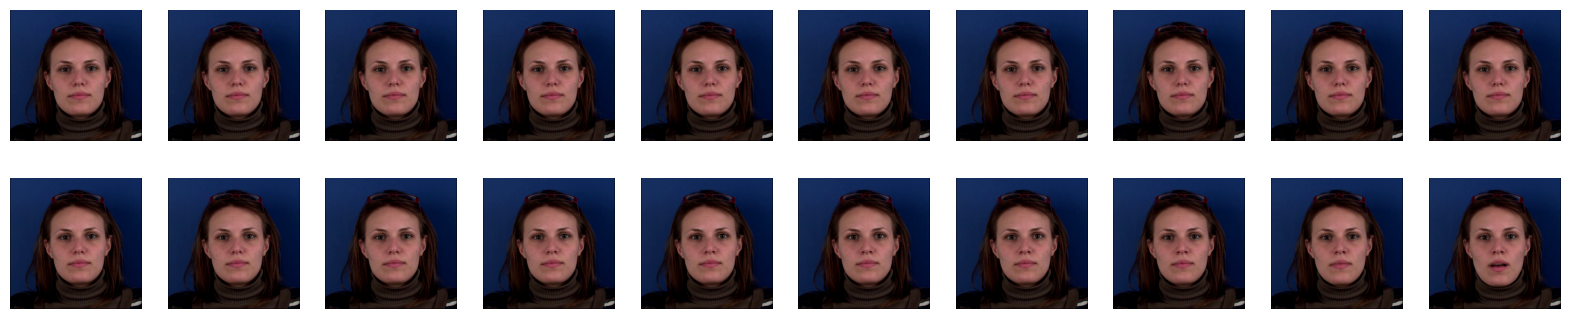

In [8]:
print(videos[0].shape)
plot_normalized_sequence(videos[0])